In [1]:
# Load dependencies
import pandas as pd
import numpy as np

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px
import nbformat

In [2]:
# Read the dataset
chicago_taxi_dataframe = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

# updates daataframe to use specific columns.
training_df = chicago_taxi_dataframe.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]
training_df.head(200)

,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [3]:
# View dataset statistics
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

# What is the maximum fare?
# max_fare = training_df['FARE'].max()
max_fare = training_df['FARE'].describe()['max']
print(f"What is the maximum fare?  Answer: ${max_fare:.2f}")


# What is the mean distance across all trips?
# mean_distance = training_df['TRIP_MILES'].mean()
mean_distance = training_df['TRIP_MILES'].describe()['mean']
print(f"What is the mean distance across all trips? Answer: {mean_distance:.4f}")

# How many cabs companies are in the dataset?
# num_unique_companies = len(training_df['COMPANY'].unique())
num_unique_companies = training_df['COMPANY'].describe()['unique']
print(f"How many cabs companies are in the dataset? Answer: {num_unique_companies}")


# What is the most frequent payment type?
# most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
most_freq_payment_type = training_df['PAYMENT_TYPE'].describe()['top']
print(f"What is the most frequent payment type? Answer: {most_freq_payment_type}")

# Are any feature missing data?
missing_values = training_df.isnull().sum().sum()
print(f"Are any feature missing data? Answer:", "No" if missing_values == 0 else "Yes")


Total number of rows: 31694


What is the maximum fare?  Answer: $159.25
What is the mean distance across all trips? Answer: 8.2895
How many cabs companies are in the dataset? Answer: 31
What is the most frequent payment type? Answer: Credit Card
Are any feature missing data? Answer: No


In [4]:
# View correlation matrix
print(training_df.corr(numeric_only=True))

              TRIP_MILES  TRIP_SECONDS      FARE  TIP_RATE
TRIP_MILES      1.000000      0.800855  0.975344 -0.049594
TRIP_SECONDS    0.800855      1.000000  0.830292 -0.084294
FARE            0.975344      0.830292  1.000000 -0.070979
TIP_RATE       -0.049594     -0.084294 -0.070979  1.000000


In [5]:
# View pairplot
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])


In [6]:
# Train Model
# Define ML functions
def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
    """Create and compile a simple linear regression model."""
    # Describe the topography of the model
    # The topography of a simple linear regression model
    # is a single node in a single layer.
    inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
    concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
    outputs = keras.layers.Dense(units=1)(concatenated_inputs)
    model = keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile the model topography into code that Keras can efficiently
    # execute. Configure training to minimize the model's mean squared error.
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
        loss="mean_squared_error",
        metrics=metrics
        )
    return model
def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
    ) -> ml_edu.experiment.Experiment:
    """Train the model by feeding it data"""
    features = {name: dataset[name].values for name in settings.input_features}
    label = dataset[label_name].values
    history = model.fit(
        x=features,
        y=label,
        batch_size=settings.batch_size,
        epochs=settings.number_epochs
        )
    return ml_edu.experiment.Experiment(
        name=experiment_name,
        settings=settings,
        model=model,
        epochs=history.epoch,
        metrics_history=pd.DataFrame(history.history),
    )


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 1429.6827 - rmse: 37.8111
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 933.0538 - rmse: 30.5459
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 545.7917 - rmse: 23.3622
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 263.6498 - rmse: 16.2373
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 90.1890 - rmse: 9.4968
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 20.3037 - rmse: 4.5060
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.5769 - rmse: 3.8180
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 14.2811 - rmse: 3.7790
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 14.1425 - rmse: 3.7607
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 14.0765 - rmse: 3.7519
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 14.0570 - rmse: 3.7493
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 14.0407 - rmse

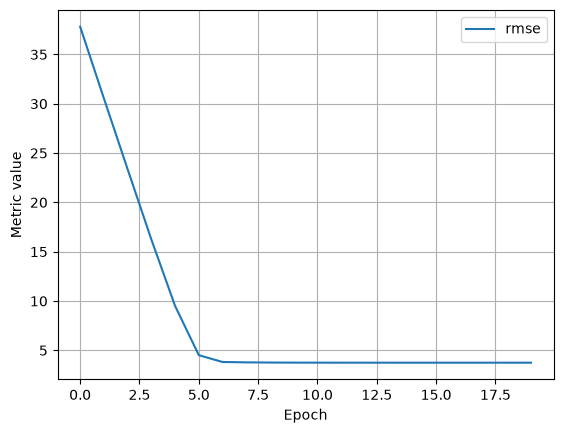

In [7]:
# Experiment 1 (Train a model with single features)
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')
    


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 49.4061 - rmse: 7.0289
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.5689 - rmse: 6.8970
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 48.0425 - rmse: 6.9313
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 48.2585 - rmse: 6.9468
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 48.0466 - rmse: 6.9316
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 48.1291 - rmse: 6.9375
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 47.6587 - rmse: 6.9035
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 47.0933 - rmse: 6.8625
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 48.0872 - rmse: 6.9345
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 47.9134 - rmse: 6.9220
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 47.7333 - rmse: 6.9089
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 48.0053 - rmse: 6.9286
E

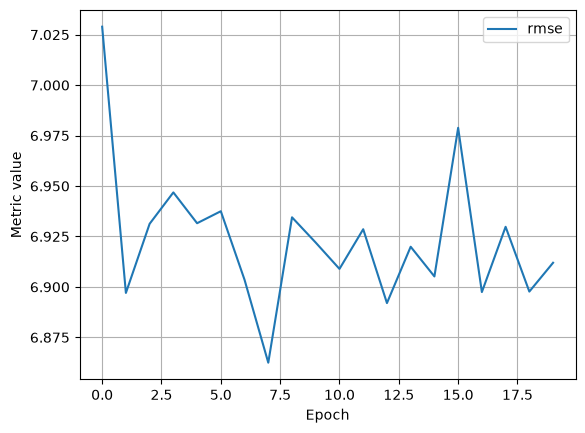

In [8]:
# Experiment 2 (Experiment 1: Increase the learning rate to 1.0 (batch size at 50))
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=1.0,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1907.2909 - rmse: 43.6725
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1844.1997 - rmse: 42.9441
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1782.0026 - rmse: 42.2138
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 1720.9076 - rmse: 41.4838
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1660.9965 - rmse: 40.7553
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1602.2192 - rmse: 40.0277
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1544.6007 - rmse: 39.3014
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1487.4999 - rmse: 38.5681
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1431.9103 - rmse: 37.8406
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1377.3048 - rmse: 37.1121
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1323.8361 - rmse: 36.3846
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step

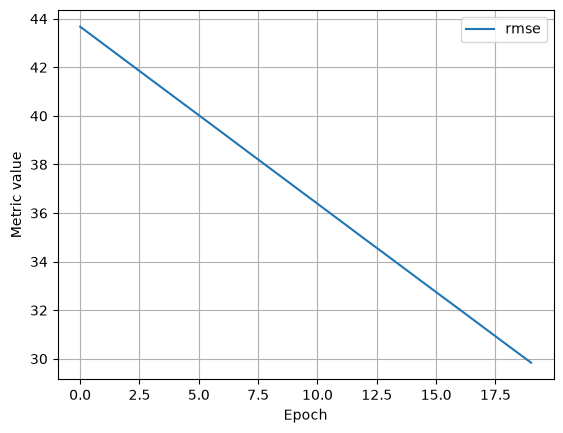

In [9]:
# Experiment 2(Experiment 2: Decrease the learning rate to 0.0001 (batch size at 50)) 
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.0001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 989.4694 - rmse: 31.4558
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 942.5471 - rmse: 30.7009
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 897.5300 - rmse: 29.9588
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 853.5311 - rmse: 29.2153
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 810.5834 - rmse: 28.4707
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 768.7752 - rmse: 27.7268
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 728.2140 - rmse: 26.9854
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 688.7245 - rmse: 26.2436
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 650.4617 - rmse: 25.5042
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 613.2198 - rmse: 24.7633
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 577.1196 - rmse: 24.0233
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 542.2171 - rmse: 23.2856
E

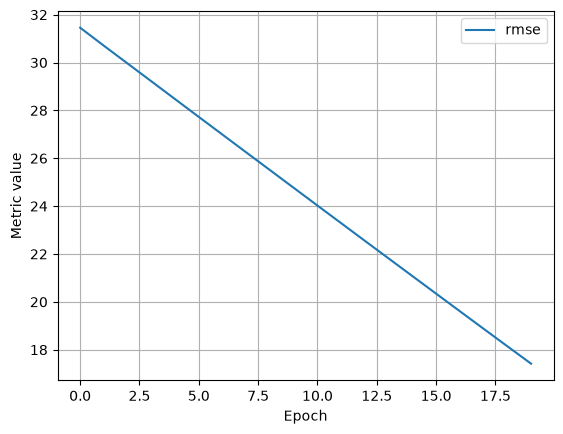

In [10]:
# Experiment 2(Experiment 3: Increase the batch size to 500 (learning rate at 0.001))
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=500,
    input_features=['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1035.6245 - rmse: 32.1811
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 173.0313 - rmse: 13.1541
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 60.9665 - rmse: 7.8081
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 37.5080 - rmse: 6.1244
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 22.3228 - rmse: 4.7247
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 15.1959 - rmse: 3.8982
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 12.9628 - rmse: 3.6004
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 12.4192 - rmse: 3.5241
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 12.2466 - rmse: 3.4995
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 12.1633 - rmse: 3.4876
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12.1307 - rmse: 3.4829
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 12.1053 - rmse: 3.4

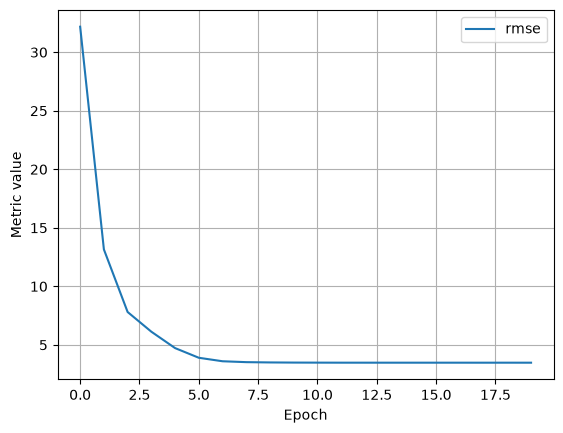

In [11]:
# Train a model with two features
# Experiment 3
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate=0.001,
    number_epochs=20,
    batch_size=50,
    input_features=['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS'] / 60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_feature', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')

In [18]:
# Model 3 weight, bias
weightBias = model_3.get_weights()
weightBias

[array([[2.0259774 ],
        [0.14718696]], dtype=float32),
 array([3.8133996], dtype=float32)]

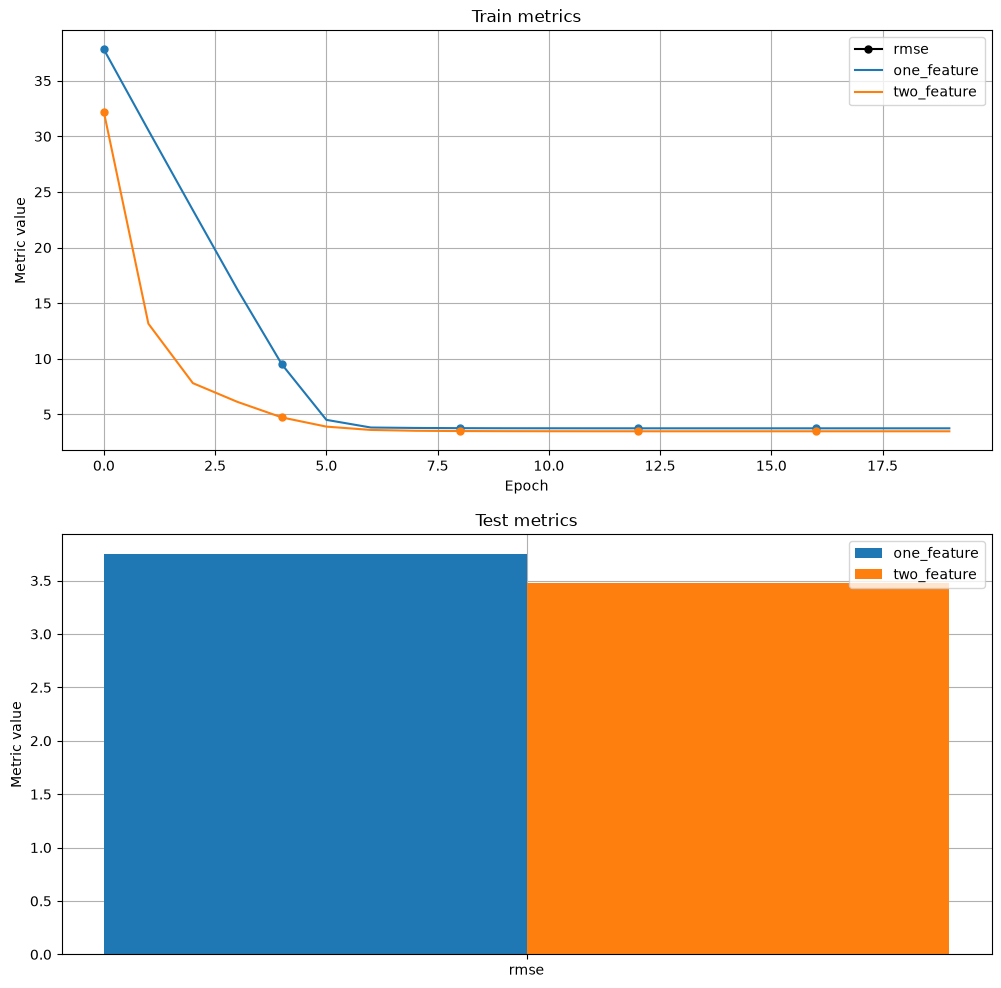

In [19]:
# Compare Experiments
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], training_df, training_df['FARE'].values)

In [24]:
# Use the model to make predictions
# Define functions to make predictions
def format_currency(x):
    return "${:.2f}".format(x)

def build_batch(df, batch_size):
    batch = df.sample(n=batch_size).copy()
    batch.set_index(np.arange(batch_size), inplace=True)
    return batch

def predict_fare(model, df, features, label, batch_size=50):
    batch = build_batch(df, batch_size)
    predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})
    
    data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [], 
            features[0]: [], features[1]: []}
    for i in range(batch_size):
        predicted = predicted_values[i][0]
        observed = batch.at[i, label]
        data["PREDICTED_FARE"].append(format_currency(predicted))
        data["OBSERVED_FARE"].append(format_currency(observed))
        data["L1_LOSS"].append(format_currency(abs(observed-predicted)))
        data[features[0]].append(batch.at[i, features[0]])
        data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))
        
    output_df = pd.DataFrame(data)
    return output_df

def show_predictions(output):
    header = "-" * 80
    banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
    print(banner)
    print(output)
    return

In [25]:
# Make the predictions
output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, "FARE")
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0          $31.29        $31.50   $0.21       12.44        15.42
1          $66.76        $72.75   $5.99       26.20        67.00
2          $12.82        $12.00   $0.82        3.50        13.00
3           $8.12         $7.75   $0.37        1.40        10.00
4           $8.18         $7.50   $0.68        1.50         9.00
5          $19.56        $19.74   $0.18        6.62        15.83
6          $37.68        $37.75   $0.07       14.90        25.00
7           $7.42         $6.75   $0.67        1.29         6.72
8          $14.54        $15.19   $0.65        4.56        10.08
9          $14.18        $13.50   $0.68        4.02        15.12
10         $27.33        $27.00   $0.33   